In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy import integrate
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import mean_absolute_percentage_error
from scipy.stats import qmc
from sklearn.preprocessing import StandardScaler

## Practica 3: Emulator for luminosity distance

#### 2 Train a Neural Network for the luminosity distance

In [4]:
# Generate a function that calculate the luminosity distance for a given redshift, a H0 and a Ωm value.
# constants for units 
c = 299792.458 # speed of light in km/s
H0 = 70.0 # Hubble constant in km/s/Mpc
Omega_m = 0.3 # Matter density parameter
Omega_L = 0.7 # Dark energy density parameter

In [5]:
def E(z, Omega_m):
    Omega_Lambda = 1.0 - Omega_m
    return np.sqrt(Omega_m * (1 + z)**3 + Omega_Lambda)

def luminosity_distance(z, H0, Omega_m):
    z = np.atleast_1d(z).astype(float)
    result = np.zeros_like(z)
    for i, zi in enumerate(z):
        if zi <= 0:
            result[i] = 0.0
            continue
        integral_val, _ = integrate.quad(lambda zp: 1.0 / E(zp, Omega_m), 0, zi)
        result[i] = (c* (1 + zi) / H0) * integral_val
    return result


def distance_modulus(z, H0, Omega_m):
    DL = luminosity_distance(z, H0, Omega_m)
    mask = DL > 0
    mu = np.full_like(DL, np.nan)
    mu[mask] = 5.0 * np.log10(DL[mask]) + 25.0
    return mu


#### Generate training and validation samples

In [7]:
"""
Generate random samples of (z, H0, Omega_m) and compute DL and mu.
Uniform random sampling ensures coverage of the full parameter space.
"""

def generate_samples(N, z_range=(0.01, 3.0), H0_range=(60, 85), Om_range=(0.1, 0.5)):
    z = np.random.uniform(*z_range, N)
    H0 = np.random.uniform(*H0_range, N)
    Om = np.random.uniform(*Om_range, N)
    
    DL = np.array([luminosity_distance(z[i], H0[i], Om[i])[0] for i in range(N)])
    mu = 5.0 * np.log10(DL) + 25.0
    
    X = np.column_stack([z, H0, Om])
    return X, DL, mu

In [ ]:
# Generate data
N_train = 30000
N_val = 8000
X_train, DL_train, mu_train = generate_samples(N_train)
X_val, DL_val, mu_val = generate_samples(N_val)

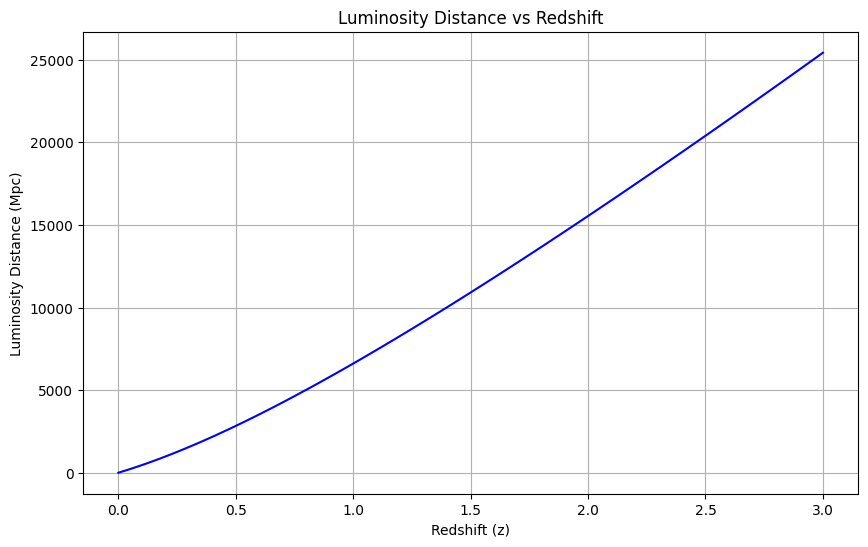

In [10]:
z_values = np.linspace(0.001, 3, 100)  

d_L_values = [luminosity_distance(z, H0, Omega_m) for z in z_values]

plt.figure(figsize=(10, 6))
plt.plot(z_values, d_L_values, label='Luminosity Distance', color='blue')
plt.xlabel('Redshift (z)')
plt.ylabel('Luminosity Distance (Mpc)')
plt.title('Luminosity Distance vs Redshift')
plt.grid()
plt.show()

In [4]:
'''
Create trainning and validation samples that covers z ∈ (0, 3), H0 ∈ (60, 85), and Ωm ∈ (0.1, 0.5). This
time, we do not give you the size of the samples, you have to define it.
'''

# Here we use the Latin Hypercube Sampling algorithm to generate the training and validation samples. 
# This algorithm allows us to sample the parameter space more efficiently than random sampling.

# [z, H0, Omega_m]
lower_bounds = [0.0, 60.0, 0.1]
upper_bounds = [3.0, 85.0, 0.5]

# sample sizes
n_train = 800
n_val = 200





In [5]:
sampler = qmc.LatinHypercube(d=3)




# Train Samples
sample_train_unscaled = sampler.random(n=n_train)
sample_train = qmc.scale(sample_train_unscaled, lower_bounds, upper_bounds)
z_train, H0_train, Omega_m_train = sample_train[:, 0], sample_train[:, 1], sample_train[:, 2]

# Val Samples
sample_val_unscaled = sampler.random(n=n_val)
sample_val = qmc.scale(sample_val_unscaled, lower_bounds, upper_bounds)
z_val, H0_val, Omega_m_val = sample_val[:, 0], sample_val[:, 1], sample_val[:, 2]



In [6]:
# Targets
d_L_train = np.array([luminosity_distance(z, H0, Omega_m) for z, H0, Omega_m in zip(z_train, H0_train, Omega_m_train)])
d_L_val = np.array([luminosity_distance(z, H0, Omega_m) for z, H0, Omega_m in zip(z_val, H0_val, Omega_m_val)])



In [7]:
# 1. Scale the Inputs (z, H0, Omega_m)
input_scaler = StandardScaler()
X_train_scaled = input_scaler.fit_transform(sample_train)
X_val_scaled = input_scaler.transform(sample_val)

# 2. Scale the Outputs (Luminosity Distance)
# StandardScaler expects a 2D array, so we reshape from (N,) to (N, 1)
output_scaler = StandardScaler()
Y_train_scaled = output_scaler.fit_transform(d_L_train.reshape(-1, 1))
Y_val_scaled = output_scaler.transform(d_L_val.reshape(-1, 1))

In [8]:
# check the shapes and ranges of the re scaled data to ensure everything is correct before training the model.
print(f"Train shapes: z={X_train_scaled.shape}, H0={H0_train.shape}, Omega_m={Omega_m_train.shape}")
print(f"H0 Train Min/Max: {H0_train.min():.2f} / {H0_train.max():.2f}")
print(f"Val shapes: z={X_val_scaled.shape}, H0={H0_val.shape}, Omega_m={Omega_m_val.shape}")
print(f"H0 Val Min/Max: {H0_val.min():.2f} / {H0_val.max():.2f}")

Train shapes: z=(800, 3), H0=(800,), Omega_m=(800,)
H0 Train Min/Max: 60.02 / 84.99
Val shapes: z=(200, 3), H0=(200,), Omega_m=(200,)
H0 Val Min/Max: 60.02 / 84.97


In [9]:
# --- Neural Network ---
model = keras.Sequential([
    keras.layers.Input(shape=(3,)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')


callback = keras.callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
# Train the model on the SCALED data
history = model.fit(
    x=X_train_scaled, 
    y=Y_train_scaled, 
    validation_data=(X_val_scaled, Y_val_scaled),
    epochs=100, 
    batch_size=32,
    verbose=1,
    callbacks=[callback]
)

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6269 - val_loss: 0.0755
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0480 - val_loss: 0.0133
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0099 - val_loss: 0.0060
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0047 - val_loss: 0.0036
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0029 - val_loss: 0.0025
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0022 - val_loss: 0.0018
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0015 - val_loss: 0.0015
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0015 - val_loss: 0.0013
Epoch 9/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0012 - val_loss: 0.0011
Epoch 10/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0011 - val_loss: 0.0010
Epoch 11/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 9.6109e-04 - val_loss: 9.0675e-04
Epoch 12/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - l

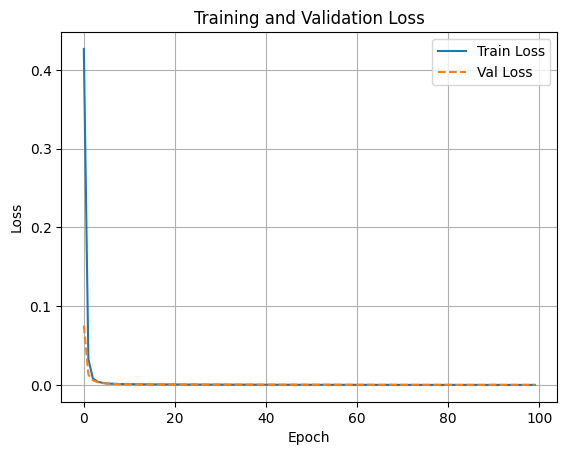

In [10]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss', linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid()
plt.show()

### Create an emulator of the distance modulus
#### using the formula 
$$

\mu  = 5 \log_{10} \left( \frac{D_L(z)}{10\; pc}\right)
$$

In [11]:
# 5) Generate the Training and Validation set for the distance modulus for the same range of redshift, H0, and a Ωm.

distance_modulus_train = 5 * np.log10(d_L_train * 1e6 / 10)  # Convert Mpc to pc and apply the formula
distance_modulus_val = 5 * np.log10(d_L_val * 1e6 / 10)  # Convert Mpc to pc and apply the formula

In [12]:
# 6) Create a Neural Network that allows for reproducing, with less than 1% error for the 95% best cases of the 
# Validation set, the distance modulus.


model_distance_modulus = keras.Sequential([
    keras.layers.Input(shape=(3,)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(1)
])

model_distance_modulus.compile(optimizer='adam', loss='mean_squared_error')
callback_distance_modulus = keras.callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
history_distance_modulus = model_distance_modulus.fit(
    x=X_train_scaled, 
    y=distance_modulus_train.reshape(-1, 1), 
    validation_data=(X_val_scaled, distance_modulus_val.reshape(-1, 1)),
    epochs=100, 
    batch_size=32,
    verbose=1,
    callbacks=[callback_distance_modulus]
)

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1889.8492 - val_loss: 1773.8540
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1710.7023 - val_loss: 1468.9365
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1362.2501 - val_loss: 997.1385
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 861.2206 - val_loss: 469.6578
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 367.8608 - val_loss: 137.5362
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 103.4822 - val_loss: 66.0432
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 67.0739 - val_loss: 60.6393
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 59.9930 - val_loss: 57.8251
Epoch 9/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 56.8747 - val_loss: 55.4417
Epoch 10/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 51.3127 - val_loss: 53.0753
Epoch 11/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 52.6765 - val_loss: 50.6996
Epoch 12/100
25/25 ━━━━━━

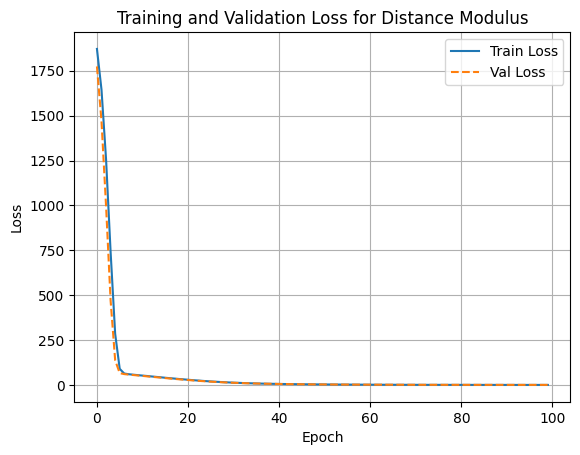

In [13]:
plt.plot(history_distance_modulus.history['loss'], label='Train Loss')
plt.plot(history_distance_modulus.history['val_loss'], label='Val Loss', linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss for Distance Modulus')
plt.legend()
plt.grid()
plt.show()

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


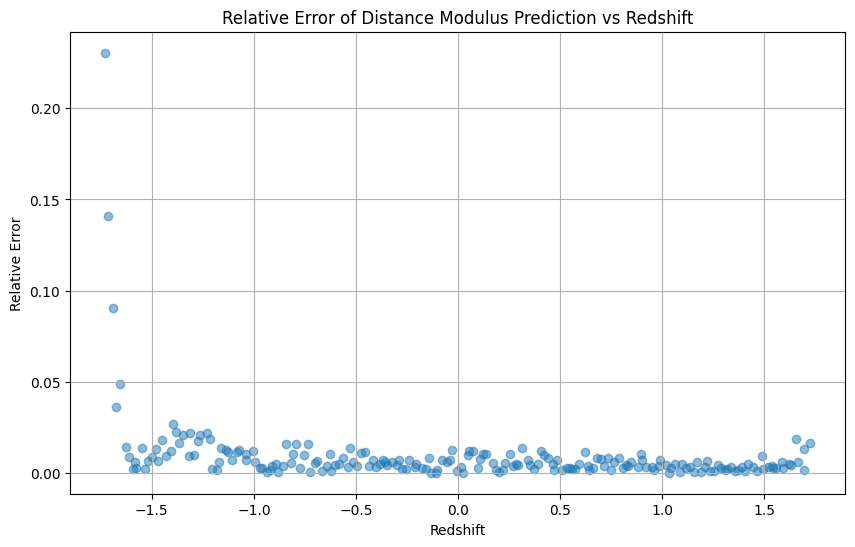

In [14]:
# 7) Plot/print the performance statistics of your Neural Network. For example, you can try to show the relative
# error of your NN depending on the redshift.

import matplotlib.pyplot as plt

y_pred = model_distance_modulus.predict(X_val_scaled)
relative_error = np.abs((y_pred - distance_modulus_val.reshape(-1, 1)) / distance_modulus_val.reshape(-1, 1))


plt.figure(figsize=(10, 6))
plt.scatter(X_val_scaled[:, 0], relative_error, alpha=0.5)
plt.xlabel('Redshift')
plt.ylabel('Relative Error')
plt.title('Relative Error of Distance Modulus Prediction vs Redshift')
plt.grid()
plt.show()


### 4 Use the emulator for studying cosmology 

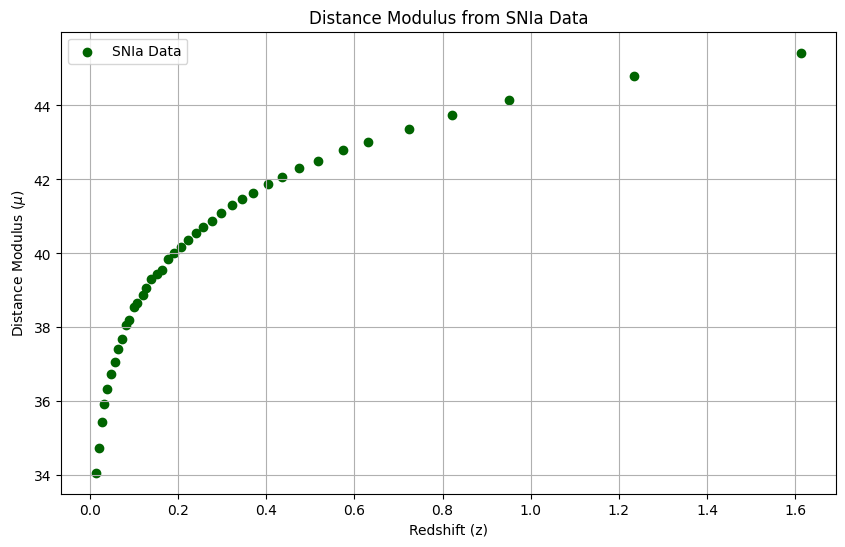

In [15]:
# 8) Read and plot the distance modulus values for Supernova experiments we provide in the file "Data_SNIa_mu.txt".


data = np.loadtxt("Data_SNIa_mu.txt", skiprows=1)
z_snia = data[:, 0]
mu_snia = data[:, 1]
plt.figure(figsize=(10, 6))
plt.scatter(z_snia, mu_snia, label='SNIa Data', color='darkgreen', marker='o')
plt.xlabel('Redshift (z)')
plt.ylabel('Distance Modulus ($\mu$)')
plt.title('Distance Modulus from SNIa Data')
plt.legend()
plt.grid()
plt.show()  

In [16]:
# 9) Create a function that returns the value of the distance modulus, using your emulator, for the whole redshifts of the data.

def predict_distance_modulus(z, H0, Omega_m):
    # Scale the input parameters using the same scaler used for training
    input_scaled = input_scaler.transform([[z, H0, Omega_m]])
    
    # Predict the distance modulus using the trained model
    mu_pred_scaled = model_distance_modulus.predict(input_scaled)
    
    # Since we did not scale the output (distance modulus), we can return the predicted value directly
    return mu_pred_scaled[0, 0]

In [17]:
# 10) Create a function that returns the L1 distance between the data points and the prediction of the function
# created in 9), for a given value of H0 and Ωm.

def compute_l1_distance(z, H0, Omega_m):
    mu_true = mu_snia[z_snia == z]
    mu_pred = predict_distance_modulus(z, H0, Omega_m)
    return np.sum(np.abs(mu_true - mu_pred))


In [18]:
# 11) Find the best fit values using an optimizer, like in the practice 0.
from scipy.optimize import minimize

def objective_function(params):
    H0, Omega_m = params
    return compute_l1_distance(z_snia, H0, Omega_m)

initial_guess = [70, 0.3]
result = minimize(objective_function, initial_guess, bounds=[(50, 100), (0, 1)])
best_fit_values = result.x

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 2 dimensions. The detected shape was (1, 3) + inhomogeneous part.